---
**Title:** GRPO — Group Relative Policy Optimization

**Chapter:** Reinforcement Learning for LLMs

**Difficulty:** Intermediate

**Estimated Time:** 45 min

---

## 1 — Overview

In the previous notebook, **DPO** simplified PPO by removing the reward model entirely — going from 4 models down to 2. But DPO is **offline**: it trains on a fixed dataset of preference pairs and never generates new data. The model can only learn from strategies already present in the dataset.

**GRPO** (Group Relative Policy Optimization, DeepSeek 2025) takes a different path. Instead of removing the reward model, it removes the **critic / value function** — the other expensive component in PPO — while keeping **online learning**.

The key idea: estimate advantages by comparing outputs **within a group**. Generate several outputs for the same prompt, score them all, and use the group statistics as the baseline. No learned critic needed.

| Algorithm | Models in memory | Online? | Key simplification |
|---|---|---|---|
| PPO | 4 (policy + critic + ref + reward) | Yes | Clipped surrogate objective |
| DPO | 2 (policy + ref) | No | Eliminates reward model |
| **GRPO** | **2 (policy + ref)** | **Yes** | **Eliminates critic — uses group statistics** |

GRPO was used by **DeepSeek-R1** (January 2025) to achieve state-of-the-art reasoning capabilities through pure reinforcement learning.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from collections import Counter

from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import draw_group_ranking, draw_method_timeline
from mp_tutorial.formatting import info_box, comparison_table, formula_breakdown

import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


In [2]:
# -- Our tiny language model (same as notebooks 00, 01, and 02) --
VOCAB = ["I", "love", "cats", "hate", "dogs"]
V = len(VOCAB)
SEQ_LEN = 3

def decode(token_ids):
    """Convert token indices to words."""
    return " ".join(VOCAB[t] for t in token_ids.tolist())


class TinyLM(nn.Module):
    """A minimal autoregressive language model.

    Given a sequence of tokens, predicts the next token at each position.
    This is exactly what GPT does -- just with 5 words instead of 50,000.
    """
    def __init__(self, vocab_size=V, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """Forward pass (teacher-forced): returns logits at every position."""
        e = self.embed(x)
        h, _ = self.rnn(e)
        return self.head(h)  # (batch, seq_len, vocab_size)

    def log_probs_of(self, sequences):
        """Compute log P(sequence) under the current policy.

        Sums log-probabilities of tokens at positions 1, 2, ..., T-1
        (position 0 is the fixed start token).
        """
        logits = self.forward(sequences)           # (B, T, V)
        dist = torch.distributions.Categorical(logits=logits[:, :-1, :])
        per_token = dist.log_prob(sequences[:, 1:])  # (B, T-1)
        return per_token.sum(dim=1)                   # (B,)

    @torch.no_grad()
    def generate(self, batch_size, seq_len=SEQ_LEN):
        """Generate sequences autoregressively (always starts with 'I')."""
        tokens = [torch.zeros(batch_size, 1, dtype=torch.long)]
        for _ in range(seq_len - 1):
            inp = torch.cat(tokens, dim=1)
            logits = self.forward(inp)[:, -1, :]
            token = torch.distributions.Categorical(logits=logits).sample()
            tokens.append(token.unsqueeze(1))
        return torch.cat(tokens, dim=1)


def reward_fn(sequences):
    """Score sequences: +1 for 'I love cats', penalize 'hate'.

    This is our stand-in for human preferences.
    In real RLHF, a learned reward model replaces this function.
    """
    rewards = []
    for seq in sequences:
        words = [VOCAB[t] for t in seq.tolist()]
        r = 0.0
        if "love" in words and "cats" in words:
            r = 1.0
        elif "love" in words:
            r = 0.3
        if "hate" in words:
            r -= 0.5
        rewards.append(r)
    return torch.tensor(rewards)


# Quick test
model = TinyLM()
seqs = model.generate(8)
for seq in seqs:
    print(f"  {decode(seq):20s}  reward = {reward_fn(seq.unsqueeze(0)).item():+.1f}")

  I I I                 reward = +0.0
  I cats love           reward = +1.0
  I cats dogs           reward = +0.0
  I cats hate           reward = -0.5
  I love I              reward = +0.3
  I hate dogs           reward = -0.5
  I hate love           reward = -0.2
  I dogs I              reward = +0.0


## 2 — The Critic Problem

Recall from the PPO notebook: the **value function** (critic) estimates "how good is this state?" — that is, the expected future reward from a given position in the sequence.

Training a good critic is **hard**:

- It needs lots of data to converge
- It can be **inaccurate**, especially early in training
- A bad critic gives bad advantage estimates, which lead to bad policy updates
- It requires its own network, optimizer, and training loop — doubling the complexity

The critic is the most fragile part of the PPO pipeline. Small errors in advantage estimation cascade into large errors in the policy gradient.

> **What if we didn't need a critic at all?**

## 3 — Group Sampling: The Core Idea

Instead of asking "how good is this state?" (which requires a learned critic), GRPO asks a simpler question:

> **"How good is this output compared to other outputs for the same prompt?"**

The recipe:

1. **Generate G outputs** for the same prompt
2. **Score them all** with the reward function
3. **Advantage = how much better/worse than the group average**

That is it. No learned model, no training loop for the critic — just a simple statistical calculation.

**Analogy:** You don't need a professor to grade an exam if you can compare all the students' answers. The best answers are above average, the worst are below. The ranking emerges from the group itself.

In [3]:
info_box("GRPO replaces a <b>learned model</b> (the critic) with a simple "
         "<b>statistical calculation</b> (group mean and std). "
         "This is both simpler and more robust — no risk of a badly trained critic "
         "corrupting your policy updates.",
         title="The Key Insight")

## 4 — Group-Relative Advantage

The **group-relative advantage** for the $i$-th output in a group of $G$ is:

$$A_i = \frac{r_i - \text{mean}(r_1, \ldots, r_G)}{\text{std}(r_1, \ldots, r_G)}$$

This is simply a **z-score** — how many standard deviations above or below the group mean.

| Component | Meaning |
|---|---|
| $r_i$ | Reward for the $i$-th output |
| $\text{mean}(r_1, \ldots, r_G)$ | Group average — serves as our **baseline** (replaces the critic) |
| $\text{std}(r_1, \ldots, r_G)$ | Normalization — puts advantages on a standard scale |
| $A_i > 0$ | Output is **better than average** — reinforce it |
| $A_i < 0$ | Output is **worse than average** — discourage it |

Notice the elegance: the baseline is automatically calibrated to the current policy's ability level. As the policy improves, the group mean rises, and only outputs that are better *relative to the new level* get positive advantage.

In [4]:
torch.manual_seed(42)
policy = TinyLM()

# Generate a group of 8 outputs
group = policy.generate(8)
scores = reward_fn(group).numpy()
labels = [decode(s) for s in group]

print("Group of 8 generated sequences:")
for label, score in zip(labels, scores):
    print(f"  {label:20s}  reward = {score:+.2f}")

mean = scores.mean()
std = scores.std()
advantages = (scores - mean) / (std + 1e-8)

print(f"\nGroup mean = {mean:.2f}")
print(f"Group std  = {std:.2f}")
print(f"\nAdvantages (z-scores):")
for label, adv in zip(labels, advantages):
    print(f"  {label:20s}  advantage = {adv:+.2f}")

Group of 8 generated sequences:
  I I I                 reward = +0.00
  I cats love           reward = +1.00
  I cats dogs           reward = +0.00
  I cats hate           reward = -0.50
  I love I              reward = +0.30
  I hate dogs           reward = -0.50
  I hate love           reward = -0.20
  I dogs I              reward = +0.00

Group mean = 0.01
Group std  = 0.45

Advantages (z-scores):
  I I I                 advantage = -0.03
  I cats love           advantage = +2.19
  I cats dogs           advantage = -0.03
  I cats hate           advantage = -1.14
  I love I              advantage = +0.64
  I hate dogs           advantage = -1.14
  I hate love           advantage = -0.47
  I dogs I              advantage = -0.03


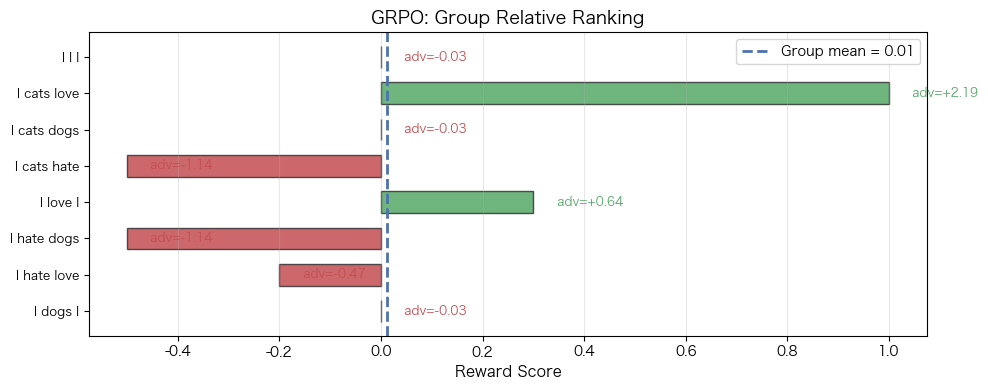

In [5]:
fig, ax = draw_group_ranking(scores, labels)
plt.show()

info_box("Green bars: above the group mean \u2192 positive advantage (reinforce). "
         "Red bars: below the mean \u2192 negative advantage (discourage). "
         "No critic model needed \u2014 just compare within the group!",
         title="GRPO: Group-Relative Advantage")

## 5 — Group Size Matters

The group size $G$ controls the quality of the advantage estimates. Larger groups give more stable estimates, but cost more compute (each output requires a forward pass through the policy).

Let us see the effect visually.

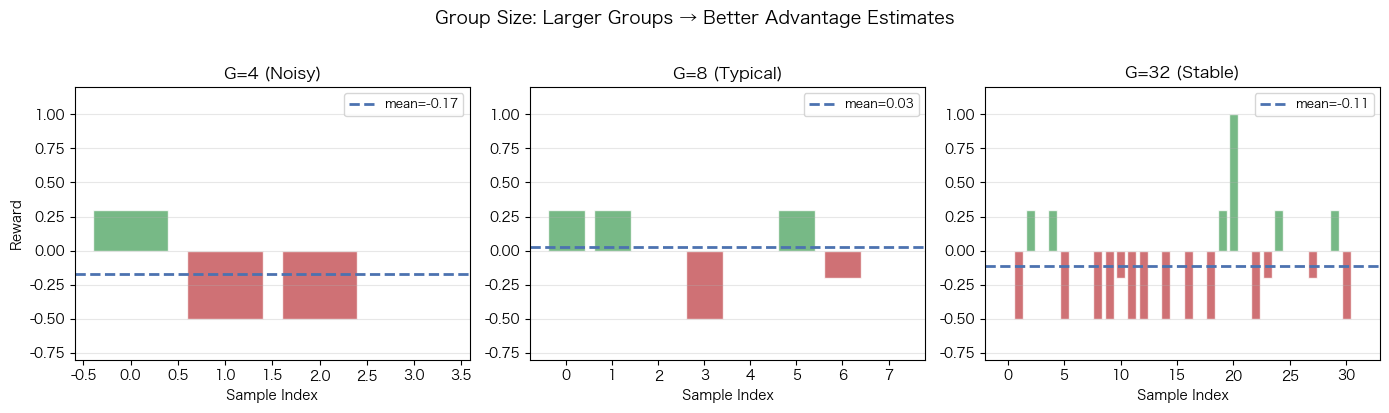

In [6]:
# Compare advantage estimates with different group sizes
torch.manual_seed(42)
policy = TinyLM()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, G, title in zip(axes, [4, 8, 32], ['G=4 (Noisy)', 'G=8 (Typical)', 'G=32 (Stable)']):
    group = policy.generate(G)
    scores_g = reward_fn(group).numpy()
    labels_g = [decode(s) for s in group]

    mean_g = scores_g.mean()
    colors_g = ['#55A868' if s > mean_g else '#C44E52' for s in scores_g]

    bars = ax.bar(range(G), scores_g, color=colors_g, edgecolor='white', alpha=0.8)
    ax.axhline(y=mean_g, color='#4C72B0', linestyle='--', lw=2,
               label=f'mean={mean_g:.2f}')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Reward" if ax == axes[0] else "")
    ax.set_ylim(-0.8, 1.2)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Group Size: Larger Groups \u2192 Better Advantage Estimates",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box("With G=4, the mean is noisy \u2014 one outlier shifts it a lot. "
         "With G=32, the mean is stable and advantages are reliable. "
         "DeepSeek-R1 uses G=8 to 64 depending on the task.",
         title="Group Size Trade-off")

## 6 — GRPO vs PPO: What Changed?

Both PPO and GRPO compute advantages and use them to update the policy. The difference is **where the baseline comes from**:

- **PPO**: uses a **learned value function** $V(s)$ as the baseline. This is a neural network that must be trained alongside the policy.
- **GRPO**: uses the **group mean** as the baseline. This is a simple statistic computed from the current batch — no model to train.

Both approaches produce advantage estimates that center around zero (good outputs get positive advantage, bad outputs get negative). But GRPO's baseline is **free** — no extra model, no extra training, no risk of a badly-calibrated critic.

In [7]:
comparison_table(
    headers=["Component", "PPO", "GRPO"],
    rows=[
        ["Baseline / Critic", "Learned value function V(s)", "Group mean (no model)"],
        ["Advantage", "GAE(\u03bb) = \u03a3(\u03b3\u03bb)^t \u00b7 \u03b4_t", "A_i = (r_i \u2212 mean) / std"],
        ["Models in memory", "4 (policy + value + ref + reward)", "2 (policy + ref)"],
        ["Training", "Multi-epoch on collected batch", "Multi-epoch on collected batch"],
        ["Online?", "Yes", "Yes"],
        ["Extra compute", "Value function forward/backward", "Generate G outputs per prompt"],
    ],
    title="PPO vs GRPO"
)

Component,PPO,GRPO
Baseline / Critic,Learned value function V(s),Group mean (no model)
Advantage,GAE(λ) = Σ(γλ)^t · δ_t,A_i = (r_i − mean) / std
Models in memory,4 (policy + value + ref + reward),2 (policy + ref)
Training,Multi-epoch on collected batch,Multi-epoch on collected batch
Online?,Yes,Yes
Extra compute,Value function forward/backward,Generate G outputs per prompt


In [8]:
formula_breakdown([
    ("Generate G outputs for each prompt",
     "y\u2081, ..., y_G ~ \u03c0_\u03b8(\u00b7|x)",
     "group = policy.generate(G)"),
    ("Score each output",
     "r_i = R(y_i)",
     "rewards = reward_fn(group)"),
    ("Group-relative advantage<br>(z-score normalization)",
     "A_i = (r_i \u2212 \u03bc_G) / \u03c3_G",
     "adv = (rewards - rewards.mean()) / (rewards.std() + 1e-8)"),
    ("Policy gradient with KL penalty",
     "L = \u2212E[log \u03c0_\u03b8(y_i) \u00b7 A_i] + \u03b2\u00b7KL",
     "loss = -(lp * adv).mean() + kl_coeff * kl"),
], title="GRPO \u2014 Step by Step")

In Plain English,Math,PyTorch
Generate G outputs for each prompt,"y₁, ..., y_G ~ π_θ(·|x)",group = policy.generate(G)
Score each output,r_i = R(y_i),rewards = reward_fn(group)
Group-relative advantage(z-score normalization),A_i = (r_i − μ_G) / σ_G,adv = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
Policy gradient with KL penalty,L = −E[log π_θ(y_i) · A_i] + β·KL,loss = -(lp * adv).mean() + kl_coeff * kl


In [9]:
# ── Train with GRPO ──
torch.manual_seed(42)
policy = TinyLM()
ref_model = deepcopy(policy)
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=3e-3)
group_size = 16
kl_coeff = 0.15

grpo_rewards = []
grpo_kl_hist = []

for step in range(300):
    # 1. Generate a group of outputs
    seqs = policy.generate(group_size)
    rewards = reward_fn(seqs)

    # 2. Group-relative advantages (z-score)
    adv = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    # 3. Policy gradient + KL penalty
    new_lp = policy.log_probs_of(seqs)
    with torch.no_grad():
        ref_lp = ref_model.log_probs_of(seqs)
    kl = (new_lp - ref_lp).mean()
    loss = -(new_lp * adv.detach()).mean() + kl_coeff * kl

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    grpo_rewards.append(rewards.mean().item())
    grpo_kl_hist.append(kl.item())

    if step % 60 == 0:
        print(f"Step {step:3d}  reward = {rewards.mean():.3f}  kl = {kl.item():.4f}")

# Check what the GRPO-trained model generates
print("\nAfter GRPO training:")
seqs = policy.generate(200)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(8):
    r = reward_fn(torch.tensor([[VOCAB.index(w) for w in text.split()]])).item()
    print(f"  {text:20s}  freq={count/200:.0%}  reward={r:+.1f}")

Step   0  reward = 0.050  kl = -0.0000
Step  60  reward = 0.456  kl = 1.8307
Step 120  reward = 0.956  kl = 2.7463
Step 180  reward = 1.000  kl = 3.0414


Step 240  reward = 1.000  kl = 3.3536

After GRPO training:
  I love cats           freq=85%  reward=+1.0
  I cats love           freq=14%  reward=+1.0
  I I cats              freq=0%  reward=+0.0
  I love love           freq=0%  reward=+0.3


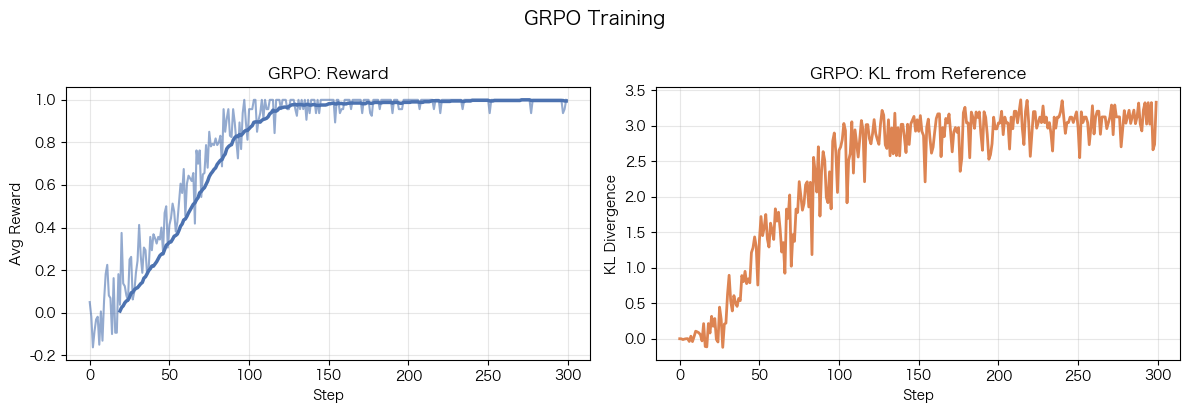

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(grpo_rewards, color='#4C72B0', lw=1.5, alpha=0.6)
window = 20
smoothed = np.convolve(grpo_rewards, np.ones(window)/window, mode='valid')
ax1.plot(range(window-1, len(grpo_rewards)), smoothed, color='#4C72B0', lw=2.5)
ax1.set_title("GRPO: Reward", fontweight='bold')
ax1.set_xlabel("Step"); ax1.set_ylabel("Avg Reward"); ax1.grid(alpha=0.3)

ax2.plot(grpo_kl_hist, color='#DD8452', lw=2)
ax2.set_title("GRPO: KL from Reference", fontweight='bold')
ax2.set_xlabel("Step"); ax2.set_ylabel("KL Divergence"); ax2.grid(alpha=0.3)

plt.suptitle("GRPO Training", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box("The reward climbs as the model learns to produce high-reward sequences. "
         "KL divergence grows as the policy moves away from the reference \u2014 "
         "the KL penalty keeps this drift in check.",
         title="GRPO Training Dynamics")

## 7 — Verifier-Based Rewards

In many practical tasks, we have a **verifier** instead of a learned reward model:

| Task | Verifier | Reward |
|---|---|---|
| **Math** | Check if the answer is correct | 1 (correct) or 0 (wrong) |
| **Code** | Run unit tests | Fraction of tests passed |
| **Factual QA** | Check against ground truth | 1 (correct) or 0 (wrong) |

This is a perfect fit for GRPO:

- The reward signal is **simple and objective** — no need for a learned reward model
- Binary rewards (correct/incorrect) work well with group-relative advantages: correct outputs get positive advantage, incorrect ones get negative
- **DeepSeek-R1** used exactly this approach: math and code verification as the reward signal

In [11]:
# Simulated math verification reward
def math_verifier(generated_answers, correct_answer=42):
    "Reward = 1 if answer matches, 0 otherwise."
    rewards = []
    for ans in generated_answers:
        # Simulate: some outputs are correct, most are wrong
        # Using a simple hash-like function for determinism
        if ans.sum().item() % 5 == 0:  # ~20% chance of "correct"
            rewards.append(1.0)
        else:
            rewards.append(0.0)
    return torch.tensor(rewards)

# Demo: generate a group and verify
torch.manual_seed(42)
policy = TinyLM()
group = policy.generate(16)
math_rewards = math_verifier(group)

print("Math verification (simulated):")
print(f"  Correct: {math_rewards.sum():.0f}/{len(math_rewards)}")
print(f"  Accuracy: {math_rewards.mean():.0%}")

# With GRPO, only the correct ones get positive advantage
advantages = (math_rewards - math_rewards.mean()) / (math_rewards.std() + 1e-8)
print(f"\nAdvantages:")
for i in range(min(8, len(group))):
    status = "\u2713" if math_rewards[i] > 0 else "\u2717"
    print(f"  {status} {decode(group[i]):20s}  reward={math_rewards[i]:.0f}  advantage={advantages[i]:+.2f}")

info_box("With binary rewards (correct/incorrect), GRPO naturally pushes the model "
         "toward outputs that pass verification. This is why it works so well for "
         "<b>math and code</b> tasks \u2014 the reward is objective and unambiguous.",
         title="Verifier-Based GRPO")

Math verification (simulated):
  Correct: 1/16
  Accuracy: 6%

Advantages:
  ✗ I I love              reward=0  advantage=-0.25
  ✗ I cats love           reward=0  advantage=-0.25
  ✗ I cats I              reward=0  advantage=-0.25
  ✗ I cats I              reward=0  advantage=-0.25
  ✗ I love I              reward=0  advantage=-0.25
  ✗ I hate love           reward=0  advantage=-0.25
  ✗ I hate hate           reward=0  advantage=-0.25
  ✗ I dogs I              reward=0  advantage=-0.25


## 8 — DeepSeek-R1: GRPO in Practice

**DeepSeek-R1** (January 2025) demonstrated that pure reinforcement learning can teach a model to reason — without any supervised fine-tuning on human-written chain-of-thought examples.

### How It Worked

1. **Start with a pre-trained base model** (no instruction tuning, no SFT)
2. **Apply GRPO** with math and code verification as the reward signal
3. **Use large group sizes** (G = 64) for stable advantage estimates
4. **Train for many iterations** on diverse math and code problems

### What Emerged

The model **spontaneously developed "chain of thought" reasoning**. Without ever being shown examples of step-by-step reasoning, the model learned to:

- Break problems into sub-steps
- Check its own work
- Backtrack when a reasoning path fails
- Verify answers before committing

This was one of the most striking results in AI in 2025: reasoning behavior emerged purely from the RL reward signal.

In [12]:
info_box("DeepSeek-R1 showed something remarkable: a model trained <b>only with GRPO</b> "
         "(no human demonstrations of reasoning) learned to 'think step by step' on its own. "
         "The secret: with enough exploration (large G), the model discovers effective strategies "
         "through trial and error.",
         title="Emergent Reasoning")

## 9 — REINFORCE vs PPO vs GRPO: Head-to-Head

Let us train all three algorithms on our toy problem and compare their learning curves on the same plot. This gives us a concrete sense of how the algorithms differ in practice.

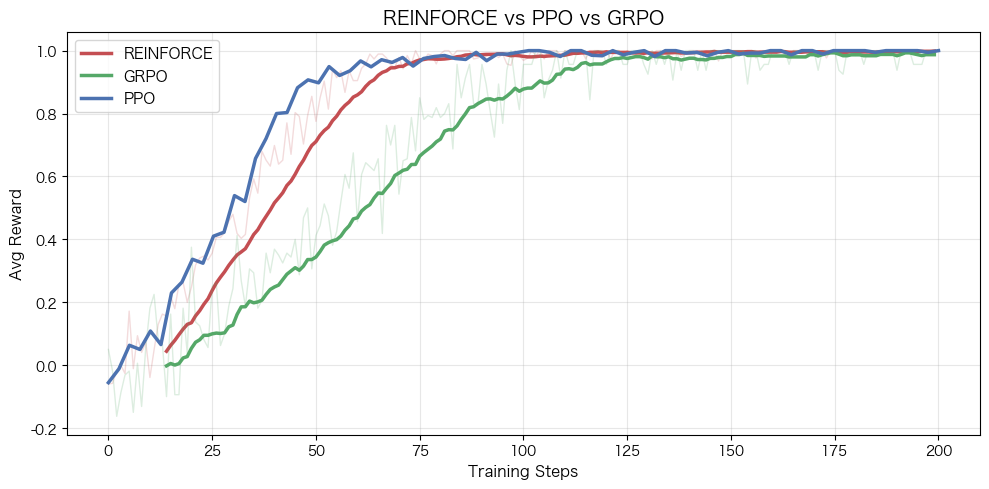

In [13]:
torch.manual_seed(42)
fig, ax = plt.subplots(figsize=(10, 5))

# ── REINFORCE ──
torch.manual_seed(42)
p_rf = TinyLM(); opt_rf = torch.optim.Adam(p_rf.parameters(), lr=5e-3)
rf_hist = []
for step in range(200):
    seqs = p_rf.generate(64); rewards = reward_fn(seqs)
    adv = rewards - rewards.mean()
    lp = p_rf.log_probs_of(seqs)
    loss = -(lp * adv).mean()
    opt_rf.zero_grad(); loss.backward(); opt_rf.step()
    rf_hist.append(rewards.mean().item())

# ── PPO ──
torch.manual_seed(42)
p_ppo = TinyLM(); ref_ppo = deepcopy(p_ppo)
for p in ref_ppo.parameters(): p.requires_grad = False
opt_ppo = torch.optim.Adam(p_ppo.parameters(), lr=3e-3)
ppo_hist = []
for epoch in range(80):
    seqs = p_ppo.generate(128); rewards = reward_fn(seqs)
    with torch.no_grad():
        old_lp = p_ppo.log_probs_of(seqs)
        ref_lp = ref_ppo.log_probs_of(seqs)
    advantages = rewards - rewards.mean()
    for _ in range(4):
        new_lp = p_ppo.log_probs_of(seqs)
        ratio = (new_lp - old_lp).exp()
        s1 = ratio * advantages
        s2 = torch.clamp(ratio, 0.8, 1.2) * advantages
        loss = -torch.min(s1, s2).mean() + 0.15 * (new_lp - ref_lp).mean()
        opt_ppo.zero_grad(); loss.backward(); opt_ppo.step()
    ppo_hist.append(rewards.mean().item())

# ── GRPO ──
torch.manual_seed(42)
p_grpo = TinyLM(); ref_grpo = deepcopy(p_grpo)
for p in ref_grpo.parameters(): p.requires_grad = False
opt_grpo = torch.optim.Adam(p_grpo.parameters(), lr=3e-3)
grpo_hist2 = []
for step in range(200):
    seqs = p_grpo.generate(16); rewards = reward_fn(seqs)
    adv = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
    new_lp = p_grpo.log_probs_of(seqs)
    ref_lp2 = ref_grpo.log_probs_of(seqs)
    kl = (new_lp - ref_lp2).mean()
    loss = -(new_lp * adv.detach()).mean() + 0.15 * kl
    opt_grpo.zero_grad(); loss.backward(); opt_grpo.step()
    grpo_hist2.append(rewards.mean().item())

# Plot all three
w = 15
for hist, color, label in [(rf_hist, '#C44E52', 'REINFORCE'),
                            (grpo_hist2, '#55A868', 'GRPO')]:
    ax.plot(hist, alpha=0.2, color=color, lw=1)
    sm = np.convolve(hist, np.ones(w)/w, mode='valid')
    ax.plot(range(w-1, len(hist)), sm, color=color, lw=2.5, label=label)

# PPO on different x-scale (epochs vs steps)
x_ppo = np.linspace(0, 200, len(ppo_hist))
ax.plot(x_ppo, ppo_hist, color='#4C72B0', lw=2.5, label='PPO')

ax.set_xlabel("Training Steps", fontsize=11)
ax.set_ylabel("Avg Reward", fontsize=11)
ax.set_title("REINFORCE vs PPO vs GRPO", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10 — When to Use What

We have now covered three different approaches to RL for LLMs. Each has its strengths:

- **GRPO**: Best for tasks with **objective, verifiable rewards** (math, code, factual QA). Simple, online, no critic. The algorithm of choice when you have a reliable reward signal.
- **DPO**: Best when you have a **fixed preference dataset** and want simplicity. Offline and stable, but limited to the strategies in the data.
- **PPO**: Best for **complex reward landscapes** where exploration matters and you need maximum flexibility. Most powerful but most expensive.

In [14]:
comparison_table(
    headers=["Scenario", "Best Algorithm", "Why"],
    rows=[
        ["Math/code with verifier", "GRPO", "Objective rewards, benefits from exploration"],
        ["Fixed preference dataset", "DPO", "Simple, offline, no generation needed"],
        ["Complex, nuanced preferences", "PPO", "Flexible, can learn subtle reward patterns"],
        ["Limited compute", "DPO", "Fewest models, no generation cost"],
        ["Want on-policy learning", "GRPO > PPO", "GRPO is simpler, PPO is more flexible"],
    ],
    title="Algorithm Selection Guide"
)

Scenario,Best Algorithm,Why
Math/code with verifier,GRPO,"Objective rewards, benefits from exploration"
Fixed preference dataset,DPO,"Simple, offline, no generation needed"
"Complex, nuanced preferences",PPO,"Flexible, can learn subtle reward patterns"
Limited compute,DPO,"Fewest models, no generation cost"
Want on-policy learning,GRPO > PPO,"GRPO is simpler, PPO is more flexible"


## Summary

### Key Takeaways

1. **GRPO replaces the learned critic** with group-relative advantages — no value function needed.
2. **Group advantage**: $A_i = (r_i - \mu) / \sigma$ — simple z-score normalization within a group of outputs.
3. **Only 2 models** needed (policy + reference), same as DPO — but GRPO is **online**.
4. **Online learning** means the model explores new strategies via generation, unlike DPO's fixed dataset.
5. **Perfect for verifiable tasks** (math, code) with objective, binary rewards.
6. **DeepSeek-R1** used GRPO to develop emergent reasoning capabilities without any supervised demonstrations.

### The Evolution So Far

| Notebook | Algorithm | Key Idea |
|---|---|---|
| 00 | REINFORCE | Policy gradient — increase probability of high-reward outputs |
| 01 | PPO | Clipped objective + KL penalty for stable updates |
| 02 | DPO | Skip the reward model — optimise preferences directly |
| **03** | **GRPO** | **Skip the critic — group-relative advantages** |
| 04 | Big Picture | How these algorithms evolved + what is next |

In [15]:
info_box("We have now covered the three main algorithms: PPO, DPO, GRPO. "
         "Next: the <b>big picture</b> \u2014 how these algorithms evolved, "
         "what is on the frontier (SAPO, online DPO), and the distributed systems "
         "challenges of training RL at scale.",
         title="What\u2019s Next")